#**NAME: KALAIVANI D**
#**REG NO: 212224060113**
#**EXP NAME: FLAT TOP SAMPLING**


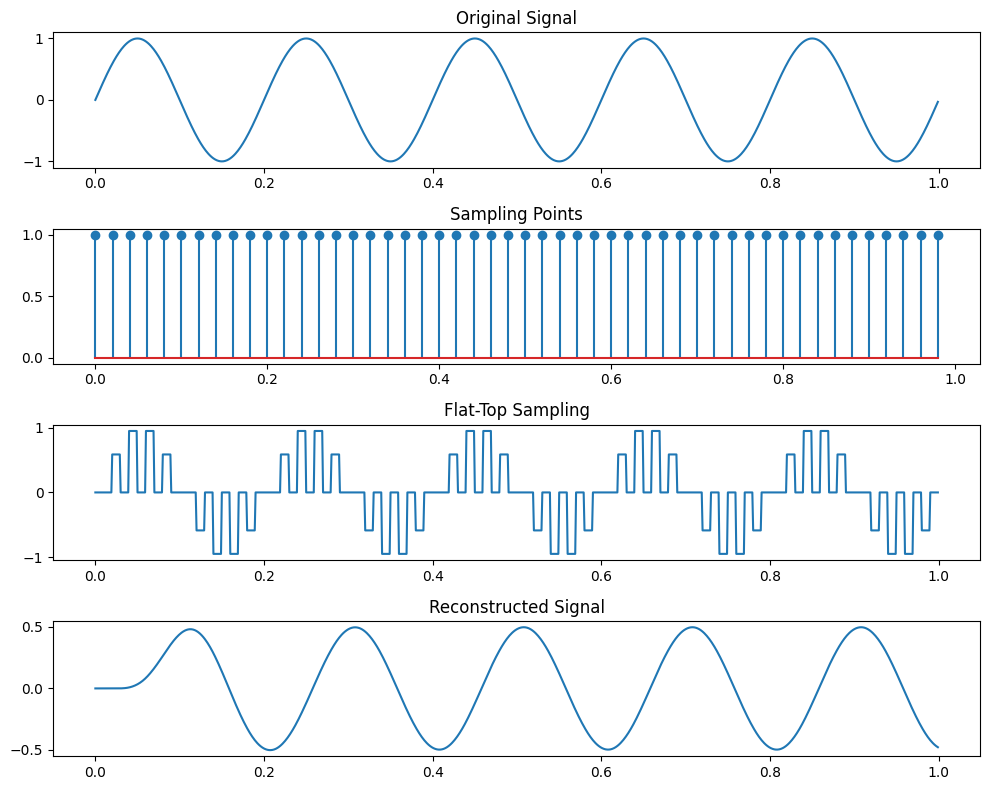

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Parameters
fs = 1000
T = 1
fm = 5

t = np.arange(0, T, 1/fs)

# Message Signal
message = np.sin(2 * np.pi * fm * t)

# Sampling
pulse_rate = 50
indices = np.arange(0, len(t), int(fs / pulse_rate))

flat_signal = np.zeros_like(t)

pulse_width = int(fs / (2 * pulse_rate))

# Flat-top Sampling
for i in indices:
    value = message[i]
    flat_signal[i:i+pulse_width] = value

# Low-pass Filter
def lowpass(signal, cutoff, fs):
    nyq = 0.5 * fs
    normal = cutoff / nyq
    b, a = butter(5, normal, btype='low')
    return lfilter(b, a, signal)

reconstructed = lowpass(flat_signal, 10, fs)

# Plots
plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(t, message)
plt.title("Original Signal")

plt.subplot(4,1,2)
plt.stem(t[indices], np.ones_like(indices))
plt.title("Sampling Points")

plt.subplot(4,1,3)
plt.plot(t, flat_signal)
plt.title("Flat-Top Sampling")

plt.subplot(4,1,4)
plt.plot(t, reconstructed)
plt.title("Reconstructed Signal")

plt.tight_layout()
plt.show()

